# 135-Model Framework: Three-State Kalman Filter

**Read-only public-release note:** this notebook now reads the saved fit/PPC CSV outputs included in `results/`. It does **not** refit the 135-model grid, delete checkpoints, simulate PPC, or run the Kalman filter.


## Three-State Kalman Filter

### State Vector
$$\mathbf{x}_t = \begin{bmatrix} \mu \\ m \\ b \end{bmatrix}$$

- $\mu$: Fast state (current duration estimate)
- $m$: Slow state (prior mean / running average)
- $b$: Bias state (serial dependence)

### State Transition
$$\mathbf{x}_t^- = F \mathbf{x}_{t-1} = \begin{bmatrix} 0 & 1 & F_{02} \\ 0 & 1 & 0 \\ 0 & 0 & \lambda \end{bmatrix} \begin{bmatrix} \mu \\ m \\ b \end{bmatrix}_{t-1}$$

### Observation Model
$$z_t = H \mathbf{x}_t + v_t, \quad H = [1, 0, 0], \quad v_t \sim \mathcal{N}(0, R)$$

### Kalman Filter Equations

**Predict:**
$$\mathbf{x}_t^- = F \mathbf{x}_{t-1}, \quad P_t^- = F P_{t-1} F^\top + Q$$

**Update:**
$$K_t = P_t^- H^\top (H P_t^- H^\top + R)^{-1}$$
$$\mathbf{x}_t = \mathbf{x}_t^- + K_t (z_t - H \mathbf{x}_t^-)$$
$$P_t = (I - K_t H) P_t^-$$

**Response:**
$$y_t = \mu_t + d_0 \quad \text{(or } y_t = \mu_t + b_t + d_0 \text{ for B3)}$$

---

## Model Space: C(15) × S(3) × B(3) = 135 Models

This notebook uses:
- **Exponential coherence modulation** for Q parameters
- **Binary step function** for R modulation

$$Q_i(c) = q_{i,base} \times e^{\alpha_{q_i} \times (1-c)}$$
$$R(c) = \begin{cases} 1 & \text{if } c \geq 0.5 \\ r_{low} & \text{if } c < 0.5 \end{cases}$$

### B-Axis: Bias Mechanism (3 levels)

| ID | Name | F[0,2] | Response | Description |
|----|------|--------|----------|-------------|
| B1 | B1 | 0 | y = μ + d0 | Bias via KF update only |
| B2 | B2 | 1 | y = μ + d0 | Bias in prediction (μ⁻ = m + b) |
| B3 | B3 | 0 | y = μ + b + d0 | Bias in response only |

---
## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr
import warnings
import gc
import time
import subprocess
import sys
warnings.filterwarnings('ignore')

# Plotting style
sns.set_theme(style='ticks', context='paper')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 8)

# =============================================================================
# CONFIG: Read saved results vs. re-run the full pipeline
# =============================================================================
# REFIT = False (default): read the saved canonical outputs under results/.
# REFIT = True: re-run the pipeline (code/04_fit_kalman.py refits the 135-model
#   grid, then code/05_validate_kalman.py regenerates PPC/validation outputs)
#   and load the regenerated results below. Refitting the grid can take hours.
REFIT = False
print(f"Mode: {'REFIT (re-run pipeline)' if REFIT else 'Reading saved results'}")

Mode: Reading saved model results


In [ ]:
# Read-only model-result helpers (no fitting, no Kalman/PPC simulation)
C_AXIS = {
    'C1': {'name': 'Q1 coherence modulation', 'description': 'Fast-state process noise depends on coherence'},
    'C2': {'name': 'Q2 coherence modulation', 'description': 'Slow-state process noise depends on coherence'},
    'C3': {'name': 'Q3 coherence modulation', 'description': 'Bias-state process noise depends on coherence'},
    'C4': {'name': 'R coherence modulation', 'description': 'Observation noise depends on coherence'},
}
for _i in range(5, 16):
    C_AXIS[f'C{_i}'] = {'name': f'Coherence model C{_i}', 'description': 'See model_fits.csv/model_ranking.csv'}
S_AXIS = {
    'S0': {'name': 'Baseline', 'description': 'No switch-specific reset'},
    'S1': {'name': 'x_reset', 'description': 'Switch reset of state mean'},
    'S2': {'name': 'k_reset', 'description': 'Switch reset of Kalman gain/covariance'},
}
B_AXIS = {
    'B1': {'name': 'B1', 'description': 'Bias via KF update only', 'F_02': 0.0, 'response_bias': False},
    'B2': {'name': 'B2', 'description': 'Bias in prediction (mu_minus = m + b)', 'F_02': 1.0, 'response_bias': False},
    'B3': {'name': 'B3', 'description': 'Bias in response only (y = mu + b + d0)', 'F_02': 0.0, 'response_bias': True},
}
N_MODELS = 135

def _axis_id(model_id, prefix):
    for part in str(model_id).split('_'):
        if part.startswith(prefix):
            return part
    return None

def rank_models(results, exp_num, criterion='AIC'):
    # Canonical per-experiment ranking. Use the saved public ranking table
    # (model_ranking.csv) when available; otherwise aggregate the per-subject fits.
    if 'model_ranking' in globals() and model_ranking is not None:
        r = (model_ranking[model_ranking['exp'] == exp_num]
             .rename(columns={'mean_AIC': 'AIC', 'mean_BIC': 'BIC', 'mean_RMSE': 'RMSE', 'n_subjects': 'n'})
             .copy())
    else:
        sub = results[(results['exp'] == exp_num) & (results.get('success', True) == True)]
        r = (sub.groupby(['model_id', 'model_name'], as_index=False)
                .agg(AIC=('AIC', 'mean'), BIC=('BIC', 'mean'), RMSE=('RMSE', 'mean'), n=('AIC', 'size')))
    # Attach axis ids and parameter count from the per-subject fit table
    meta_cols = [c for c in ['model_id', 'c_id', 's_id', 'b_id', 'n_params'] if c in results.columns]
    meta = results[results['exp'] == exp_num].drop_duplicates('model_id')[meta_cols]
    r = r.merge(meta, on='model_id', how='left')
    for ax, prefix in [('c_id', 'C'), ('s_id', 'S'), ('b_id', 'B')]:
        if ax not in r.columns:
            r[ax] = r['model_id'].map(lambda x: _axis_id(x, prefix))
    sort_col = criterion if criterion in r.columns else 'AIC'
    r = r.sort_values(sort_col).reset_index(drop=True)
    if 'delta_AIC' not in r.columns:
        r['delta_AIC'] = r['AIC'] - r['AIC'].min()
    r['Rank'] = range(1, len(r) + 1)
    r['AIC_mean'], r['BIC_mean'] = r['AIC'], r['BIC']
    return r

def get_best_model(results, exp_num, criterion='AIC'):
    ranking = rank_models(results, exp_num, criterion=criterion)
    if ranking.empty:
        raise ValueError(f'No saved ranking for experiment {exp_num}')
    best_id = ranking.iloc[0]['model_id']
    best_name = ranking.iloc[0]['model_name']
    sub = results[(results['exp'] == exp_num) & (results['model_id'] == best_id)].copy()
    return best_name, sub

def compare_axes(results, exp_num):
    sub = rank_models(results, exp_num).copy()
    return {
        'by_c': sub.groupby('c_id').agg(AIC_mean=('AIC_mean', 'mean'), BIC_mean=('BIC_mean', 'mean')),
        'by_s': sub.groupby('s_id').agg(AIC_mean=('AIC_mean', 'mean'), BIC_mean=('BIC_mean', 'mean')),
        'by_b': sub.groupby('b_id').agg(AIC_mean=('AIC_mean', 'mean'), BIC_mean=('BIC_mean', 'mean')),
    }

print(f'Read-only Kalman model helpers loaded for {N_MODELS} saved-model grid.')
print('This notebook reads included CSV outputs; it does not fit models or run the Kalman filter.')

Read-only Kalman model helpers loaded for 135 saved-model grid.
This notebook reads included CSV outputs; it does not fit models or run the Kalman filter.


### Model Space Summary

**Model Grid Size:** 135 = C(15) × S(3) × B(3)

**C-Axis (Coherence Modulation):**
- C1: Q1 coherence modulation
- C2: Q2 coherence modulation  
- C3: Q3 coherence modulation
- C4: R coherence modulation
- C5-C15: Additional coherence models

**S-Axis (Switch Effect):**
- S0: Baseline (no switch-specific reset)
- S1: x_reset (switch reset of state mean)
- S2: k_reset (switch reset of Kalman gain/covariance)

**B-Axis (Bias Mechanism):**
- B1: Bias via KF update only
- B2: Bias in prediction (μ⁻ = m + b)
- B3: Bias in response only (y = μ + b + d0)
### B-Axis Details

| ID | Name | F[0,2] | Response Model | Description |
|----|------|--------|---|---|
| B1 | Bias via KF update | 0 | y = μ + d0 | Bias incorporated only through Kalman filter update step |
| B2 | Bias in prediction | 1 | y = μ + d0 | Bias affects prediction: μ⁻ = m + b |
| B3 | Bias in response | 0 | y = μ + b + d0 | Bias added directly to response output |

---
## 2. Load Data

In [ ]:
# Paths
cwd = Path.cwd().resolve()
root = cwd.parent if cwd.name == 'notebooks' else cwd
if not (root / 'data').exists():
    raise FileNotFoundError(f"Could not find 'data/' under {root}. Run this notebook from inside the cloned repository.")
data_path = root / 'data'
output_path = root / 'results' / 'kalman_model_fits'

# Load public cleaned data for observed-data summaries only
same_set = {'HH', 'LL'}

exp1 = (pd.read_pickle(data_path / 'experiment1' / 'E1.pkl')
        .query('~is_outlier')
        .assign(exp=1,
                Structure=lambda df: np.where(df['TransitionType'].isin(same_set), 'Repeat', 'Switch'))
        .rename(columns={'curDur': 'Duration', 'curBias': 'Bias', 'rpr': 'Reproduction',
                         'curCoherence': 'coherence', 'subID': 'Sub'})
        .astype({'coherence': float, 'Sub': int}))

exp2 = (pd.read_pickle(data_path / 'experiment2' / 'E2.pkl')
        .query('~is_outlier')
        .assign(exp=2,
                Structure=lambda df: np.where(df['TransitionType'].isin(same_set), 'Repeat', 'Switch'))
        .rename(columns={'curDur': 'Duration', 'curBias': 'Bias', 'rpr': 'Reproduction',
                         'curCoherence': 'coherence', 'subID': 'Sub'})
        .astype({'coherence': float, 'Sub': int}))

df = pd.concat([exp1, exp2], ignore_index=True)
df = df[['Sub', 'exp', 'trial_num', 'coherence', 'Structure', 'Duration', 'Bias', 'Reproduction']]

---
## 3. Model Results

**Configuration:** `REFIT = False` (default, set in the config cell above) reads the saved canonical outputs under `results/kalman_model_fits/` and `results/kalman_model_checks/`.

Set `REFIT = True` to re-run the full pipeline — `code/04_fit_kalman.py` refits the 135-model grid (can take hours) and `code/05_validate_kalman.py` regenerates the PPC/validation outputs — after which the cells below load the regenerated results.

In [ ]:
# Optionally refit the full grid, then load results from disk (same path in both modes).
MODEL_DIR = root / 'results' / 'kalman_model_fits'
CHECK_DIR = root / 'results' / 'kalman_model_checks'

if REFIT:
    print("⚠️  REFITTING 135-model grid via code/04_fit_kalman.py (this may take hours)...")
    subprocess.run([sys.executable, str(root / 'code' / '04_fit_kalman.py')], check=True)

results_df = pd.read_csv(MODEL_DIR / 'model_fits_deduplicated.csv')
results_exp1 = results_df[results_df['exp'] == 1].reset_index(drop=True)
results_exp2 = results_df[results_df['exp'] == 2].reset_index(drop=True)
model_ranking = pd.read_csv(MODEL_DIR / 'model_ranking.csv')
parameter_means = pd.read_csv(MODEL_DIR / 'model_parameter_means.csv')

print("✓ Loaded model results:")
print(f"   model_fits: {len(results_df)} rows (exp1={len(results_exp1)}, exp2={len(results_exp2)})")
print(f"   model_ranking: {len(model_ranking)} rows")

✓ Loaded saved model results:


### Full fitting omitted in the public notebook

The original fitting/checkpoint cells are not executed in this public-release notebook. Use the saved CSV outputs under `results/kalman_model_fits/` for inspection.


### Full fitting omitted in the public notebook

The original fitting/checkpoint cells are not executed in this public-release notebook. Use the saved CSV outputs under `results/kalman_model_fits/` for inspection.


### Full fitting omitted in the public notebook

The original fitting/checkpoint cells are not executed in this public-release notebook. Use the saved CSV outputs under `results/kalman_model_fits/` for inspection.


In [ ]:
# Confirm saved per-experiment files are present
_ = [(exp_num, len(table), table["model_id"].nunique()) 
      for exp_num, table in [(1, results_exp1), (2, results_exp2)]]

Experiment 1: 2,970 saved fit rows; 135 models
Experiment 2: 2,970 saved fit rows; 135 models


---
## 4. Model Comparison

In [ ]:
if results_df is not None:
    
    for exp_num in [1, 2]:
        # Rank models
        ranking = rank_models(results_df, exp_num=exp_num, criterion='AIC')
        
        # Top 10
        display(ranking.head(10)[['Rank', 'model_name', 'c_id', 's_id', 'b_id',
                                   'AIC', 'delta_AIC', 'BIC', 'RMSE', 'n_params']].round(2))

,Rank,model_name,c_id,s_id,b_id,AIC,delta_AIC,BIC,RMSE,n_params
0,1,C_Q1__S_baseline__B_B2,C1,S0,B2,-116.77,0.00,-89.89,0.18,8
1,2,C_Q3__S_baseline__B_B2,C3,S0,B2,-116.47,0.30,-89.58,0.18,8
2,3,C_Q1_Q3__S_baseline__B_B2,C9,S0,B2,-116.24,0.54,-85.99,0.18,9
3,4,C_Q2__S_baseline__B_B2,C2,S0,B2,-115.80,0.97,-88.91,0.18,8
4,5,C_Q1_Q2__S_baseline__B_B2,C8,S0,B2,-115.63,1.15,-85.38,0.18,9
5,6,C_Q1__S_K_reset__B_B2,C1,S2,B2,-115.38,1.39,-85.13,0.18,9
6,7,C_Q2_Q3__S_baseline__B_B2,C10,S0,B2,-114.83,1.95,-84.58,0.18,9
7,8,C_Q1__S_x_reset__B_B2,C1,S1,B2,-114.82,1.96,-84.57,0.18,9
8,9,C_Q3__S_K_reset__B_B2,C3,S2,B2,-114.69,2.08,-84.44,0.18,9
9,10,C_Q3__S_x_reset__B_B2,C3,S1,B2,-114.60,2.17,-84.35,0.18,9


,Rank,model_name,c_id,s_id,b_id,AIC,delta_AIC,BIC,RMSE,n_params
0,1,C_Q1__S_baseline__B_B2,C1,S0,B2,-76.31,0.00,-49.49,0.2,8
1,2,C_Q3__S_x_reset__B_B2,C3,S1,B2,-76.26,0.05,-46.09,0.2,9
2,3,C_Q1__S_x_reset__B_B2,C1,S1,B2,-76.14,0.18,-45.96,0.2,9
3,4,C_Q1_Q3__S_x_reset__B_B2,C9,S1,B2,-75.88,0.43,-42.36,0.2,10
4,5,C_Q1_Q2__S_x_reset__B_B2,C8,S1,B2,-75.82,0.49,-42.30,0.2,10
5,6,C_Q3__S_baseline__B_B2,C3,S0,B2,-75.73,0.58,-48.91,0.2,8
6,7,C_Q2__S_baseline__B_B2,C2,S0,B2,-75.60,0.71,-48.78,0.2,8
7,8,C_Q1_Q3__S_baseline__B_B2,C9,S0,B2,-75.44,0.87,-45.27,0.2,9
8,9,C_Q1_R__S_x_reset__B_B2,C5,S1,B2,-75.30,1.01,-41.78,0.2,10
9,10,C_Q1_Q2__S_baseline__B_B2,C8,S0,B2,-75.13,1.18,-44.96,0.2,9


### Axis Comparison

Compare model performance marginalized over each axis to identify which factors contribute most to fit quality.

In [ ]:
# Compare by axis
if results_df is not None:
    for exp_num in [1, 2]:
        comparison = compare_axes(results_df, exp_num=exp_num)
        display(comparison['by_c'])
        display(comparison['by_s'])
        display(comparison['by_b'])


### By C-Axis (Coherence Modulation) ###


,AIC_mean,BIC_mean
c_id,,
C1,-114.074294,-84.944602
C10,-111.448074,-78.957264
C11,-109.998916,-74.146988
C12,-109.957680,-74.105752
C13,-108.516104,-72.664176
C14,-111.045411,-75.193483
C15,-108.372779,-69.159733
C2,-112.978957,-83.849266
C3,-112.750411,-83.620719



### By S-Axis (Switch Effect) ###


,AIC_mean,BIC_mean
s_id,,
S0,-112.163125,-81.464912
S1,-110.947301,-76.887970
S2,-110.386685,-76.327354



### By B-Axis (Bias Mechanism) ###


...

,AIC_mean,BIC_mean
c_id,,
C1,-74.415248,-45.359677
C10,-72.253110,-39.844973
C11,-71.447380,-35.686677
C12,-70.974223,-35.213520
C13,-70.553831,-34.793128
C14,-71.845737,-36.085034
C15,-69.823678,-30.710409
C2,-73.775401,-44.719830
C3,-73.207778,-44.152207



### By S-Axis (Switch Effect) ###


,AIC_mean,BIC_mean
s_id,,
S0,-72.570995,-41.950894
S1,-72.979799,-39.007132
S2,-71.199849,-37.227182



### By B-Axis (Bias Mechanism) ###


,AIC_mean,BIC_mean
b_id,,
B1,-71.486049,-38.630903
B2,-73.777724,-40.922579
B3,-71.486871,-38.631726


---
## 5. Visualization

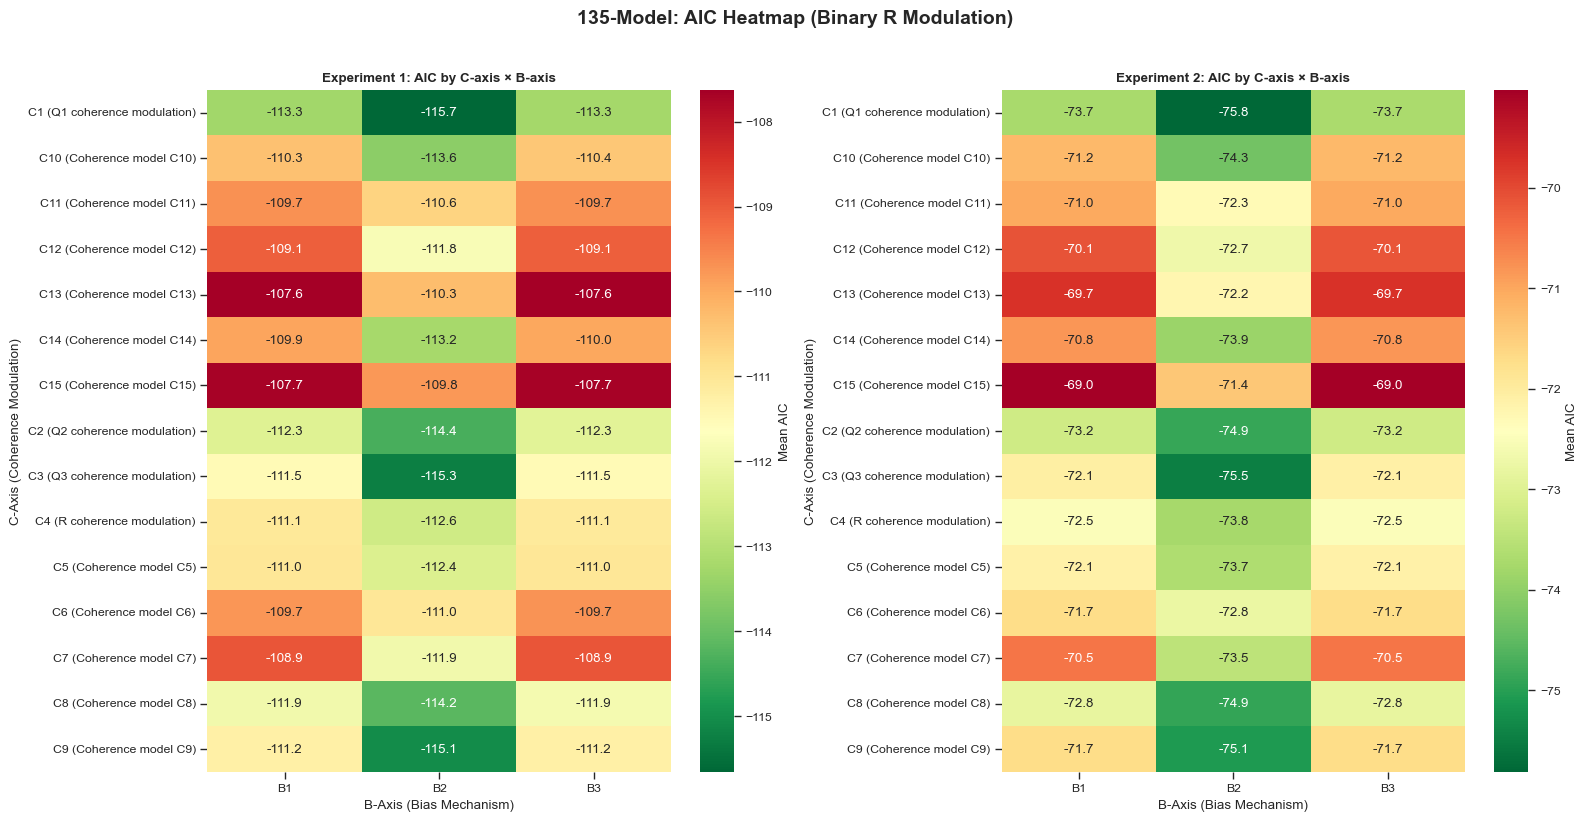

In [ ]:
# AIC heatmap by C-axis and B-axis
if results_df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    for idx, exp_num in enumerate([1, 2]):
        ax = axes[idx]
        
        exp_data = results_df[results_df['exp'] == exp_num]
        
        # Pivot: C-axis vs B-axis, mean AIC
        pivot = exp_data.groupby(['c_id', 'b_id'])['AIC'].mean().unstack()
        
        # Add C-axis names
        pivot.index = [f"{c} ({C_AXIS[c]['name']})" for c in pivot.index]
        pivot.columns = [B_AXIS[b]['name'] for b in pivot.columns]
        
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', 
                    ax=ax, cbar_kws={'label': 'Mean AIC'})
        ax.set_title(f'Experiment {exp_num}: AIC by C-axis × B-axis', fontweight='bold')
        ax.set_xlabel('B-Axis (Bias Mechanism)')
        ax.set_ylabel('C-Axis (Coherence Modulation)')
    
    plt.suptitle('135-Model: AIC Heatmap (Binary R Modulation)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(output_path / 'aic_heatmap_c_b.png', dpi=150, bbox_inches='tight')
    plt.show()

### Model Ranking

Horizontal bar chart showing ΔAIC for top 50 models. Colors indicate B-axis (bias mechanism). Vertical lines mark conventional thresholds: ΔAIC = 2 (substantial evidence) and ΔAIC = 10 (strong evidence).

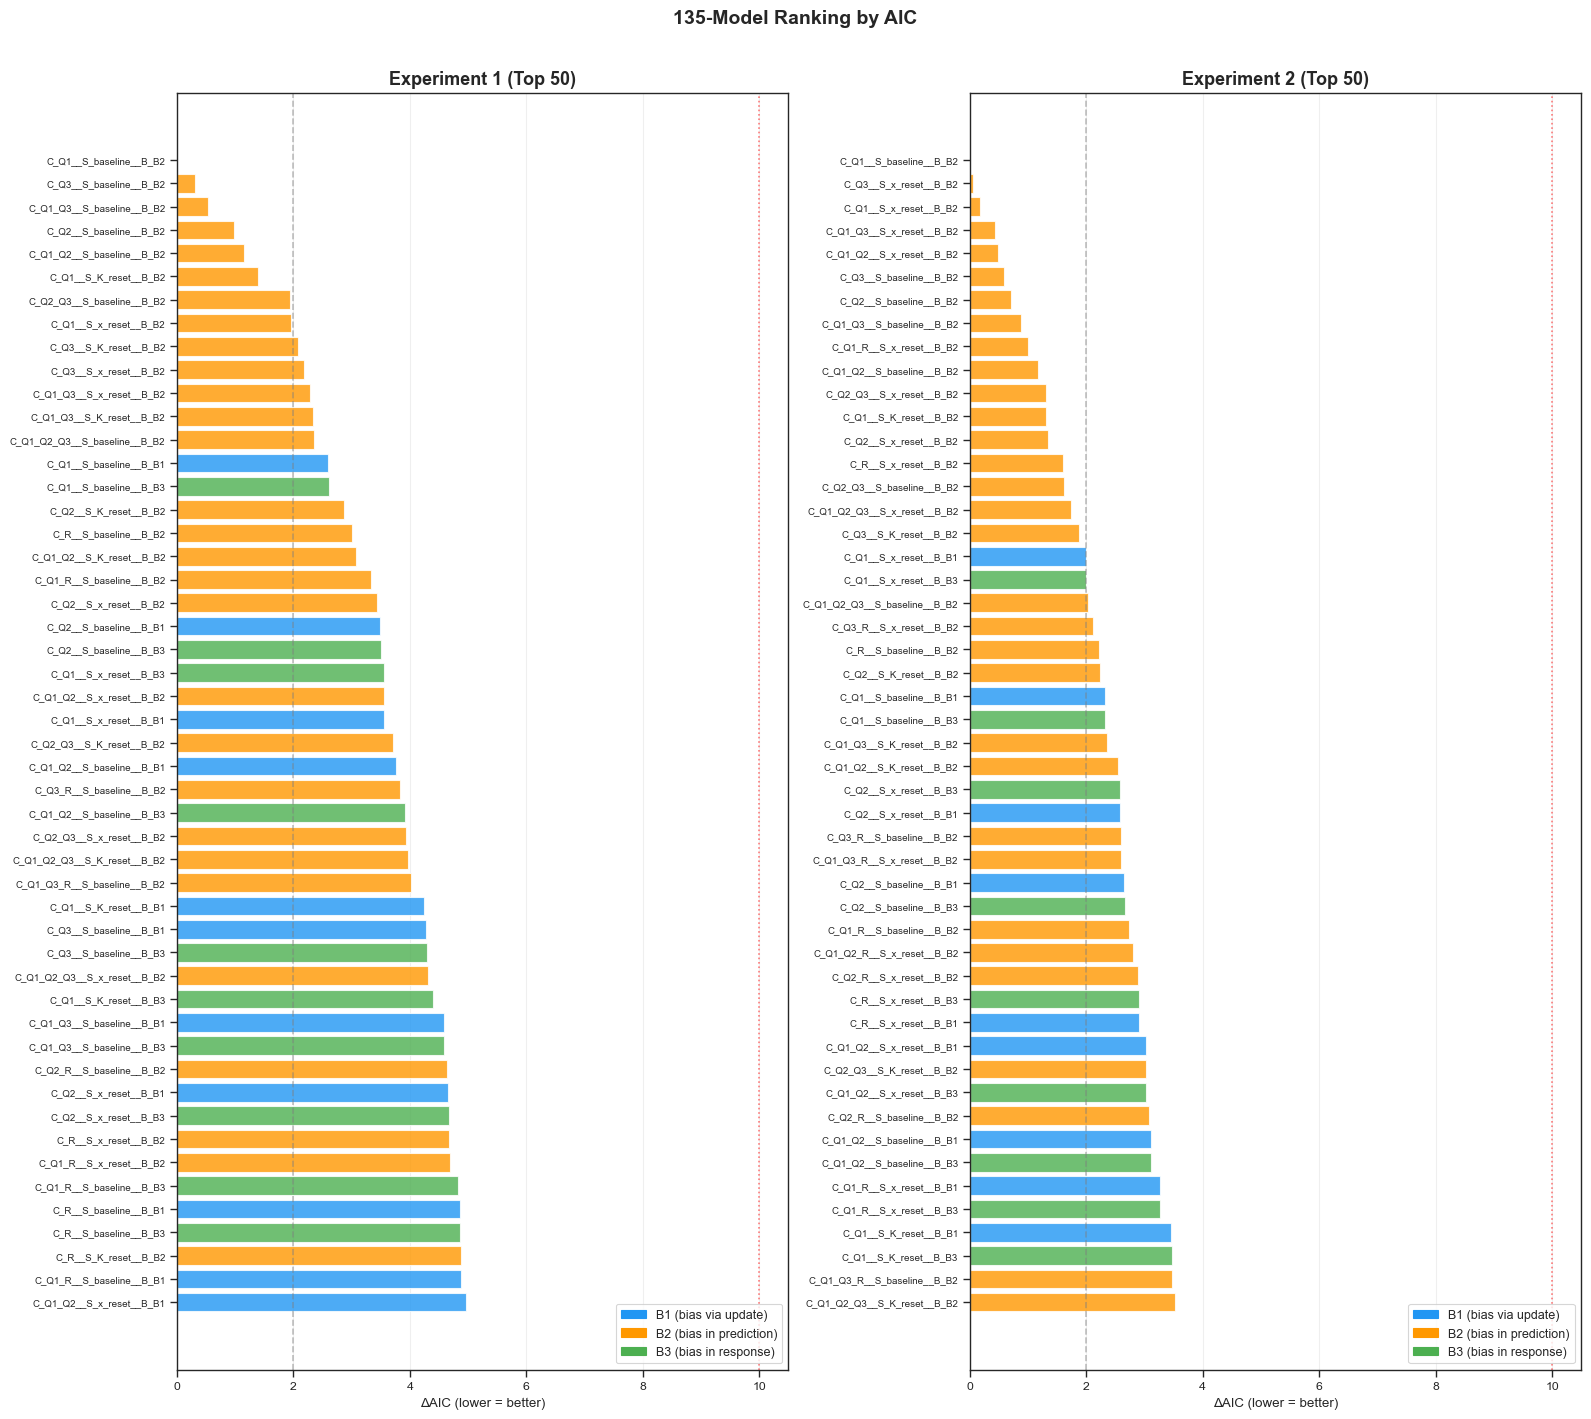

In [ ]:
# Delta AIC bar plot
if results_df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 14))
    
    # Color mapping for B-axis
    b_colors = {'B1': '#2196F3', 'B2': '#FF9800', 'B3': '#4CAF50'}
    
    for idx, exp_num in enumerate([1, 2]):
        ax = axes[idx]
        ranking = rank_models(results_df, exp_num=exp_num, criterion='AIC')
        
        # Show top 50 for readability
        top_n = ranking.head(50)
        
        # Colors by B-axis
        colors = [b_colors.get(b, 'gray') for b in top_n['b_id']]
        
        ax.barh(range(len(top_n)), top_n['delta_AIC'], color=colors, alpha=0.8)
        ax.set_yticks(range(len(top_n)))
        ax.set_yticklabels(top_n['model_name'], fontsize=7)
        ax.invert_yaxis()
        ax.set_xlabel('ΔAIC (lower = better)')
        ax.set_title(f'Experiment {exp_num} (Top 50)', fontsize=13, fontweight='bold')
        ax.axvline(x=2, color='gray', ls='--', alpha=0.5)
        ax.axvline(x=10, color='red', ls=':', alpha=0.5)
        ax.grid(axis='x', alpha=0.3)
        
        # Legend
        from matplotlib.patches import Patch
        ax.legend(handles=[
            Patch(color='#2196F3', label='B1 (bias via update)'),
            Patch(color='#FF9800', label='B2 (bias in prediction)'),
            Patch(color='#4CAF50', label='B3 (bias in response)'),
        ], loc='lower right', fontsize=9)
    
    plt.suptitle('135-Model Ranking by AIC', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(output_path / 'model_ranking.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 6. Posterior Predictive Checks (PPC)

### Central Tendency Index (CTI)
$$\text{CTI} = \text{slope}(r_t \sim s_t)$$

### Serial Dependence Index (SDI)
$$\text{SDI} = \text{slope}(\text{Bias}_t \sim s_{t-1})$$

In [ ]:
# Optionally regenerate PPC/validation outputs, then load from disk (same path in both modes).
CHECK_DIR = root / 'results' / 'kalman_model_checks'

if REFIT:
    print("⚠️  Regenerating PPC/validation via code/05_validate_kalman.py ...")
    subprocess.run([sys.executable, str(root / 'code' / '05_validate_kalman.py')], check=True)

ppc_subject_metrics = pd.read_csv(CHECK_DIR / 'winner_ppc_subject_metrics.csv')
ppc_summary = pd.read_csv(CHECK_DIR / 'winner_ppc_summary.csv')
trial_predictions = pd.read_csv(CHECK_DIR / 'winner_ppc_trial_predictions.csv')
behavioral_effects_subject = pd.read_csv(CHECK_DIR / 'winner_behavioral_effects_subject.csv')
behavioral_effects_summary = pd.read_csv(CHECK_DIR / 'winner_behavioral_effect_summary.csv')

ppc_results = {}
for exp_num in sorted(ppc_subject_metrics['exp'].unique()):
    merged = (ppc_subject_metrics[ppc_subject_metrics['exp'] == exp_num]
              .rename(columns={
                  'cti_obs': 'CTI_obs', 'cti_pred': 'CTI_sim',
                  'sdi_obs': 'SDI_obs', 'sdi_pred': 'SDI_sim',
              })
              .copy())
    summary_row = ppc_summary[ppc_summary['exp'] == exp_num].iloc[0]
    ppc_results[int(exp_num)] = {
        'merged': merged,
        'CTI_r': summary_row['cti_r'],
        'SDI_r': summary_row['sdi_r'],
        'CTI_rec': summary_row['cti_mean_pred'] / summary_row['cti_mean_obs'] * 100,
        'SDI_rec': summary_row['sdi_mean_pred'] / summary_row['sdi_mean_obs'] * 100,
        'model': summary_row['model_name'],
    }
print("✓ Loaded PPC results")

✓ Loaded saved PPC results


### PPC results from saved outputs

Subject-level PPC metrics and trial-level predictions are read from `results/kalman_model_checks/`. No new PPC simulation/Kalman filtering is run.


In [ ]:
# Saved PPC summary table
display(ppc_summary)

,exp,model_id,model_name,cti_r,cti_p,sdi_r,sdi_p,cti_mean_obs,cti_mean_pred,sdi_mean_obs,sdi_mean_pred,rmse_mean,mae_mean,n_subjects
0,1,C1_S0_B2,C_Q1__S_baseline__B_B2,0.995612,4.685881e-22,0.751338,5.569112e-05,0.619919,0.613144,0.066454,0.066307,0.182516,0.147077,22
1,2,C1_S0_B2,C_Q1__S_baseline__B_B2,0.994553,4.057054e-21,0.948949,1.756542e-11,0.510179,0.515622,0.110099,0.106957,0.199587,0.159800,22


### PPC Visualization

Scatter plots comparing observed vs. simulated CTI and SDI for each subject. Dashed line = identity; solid line = linear fit.

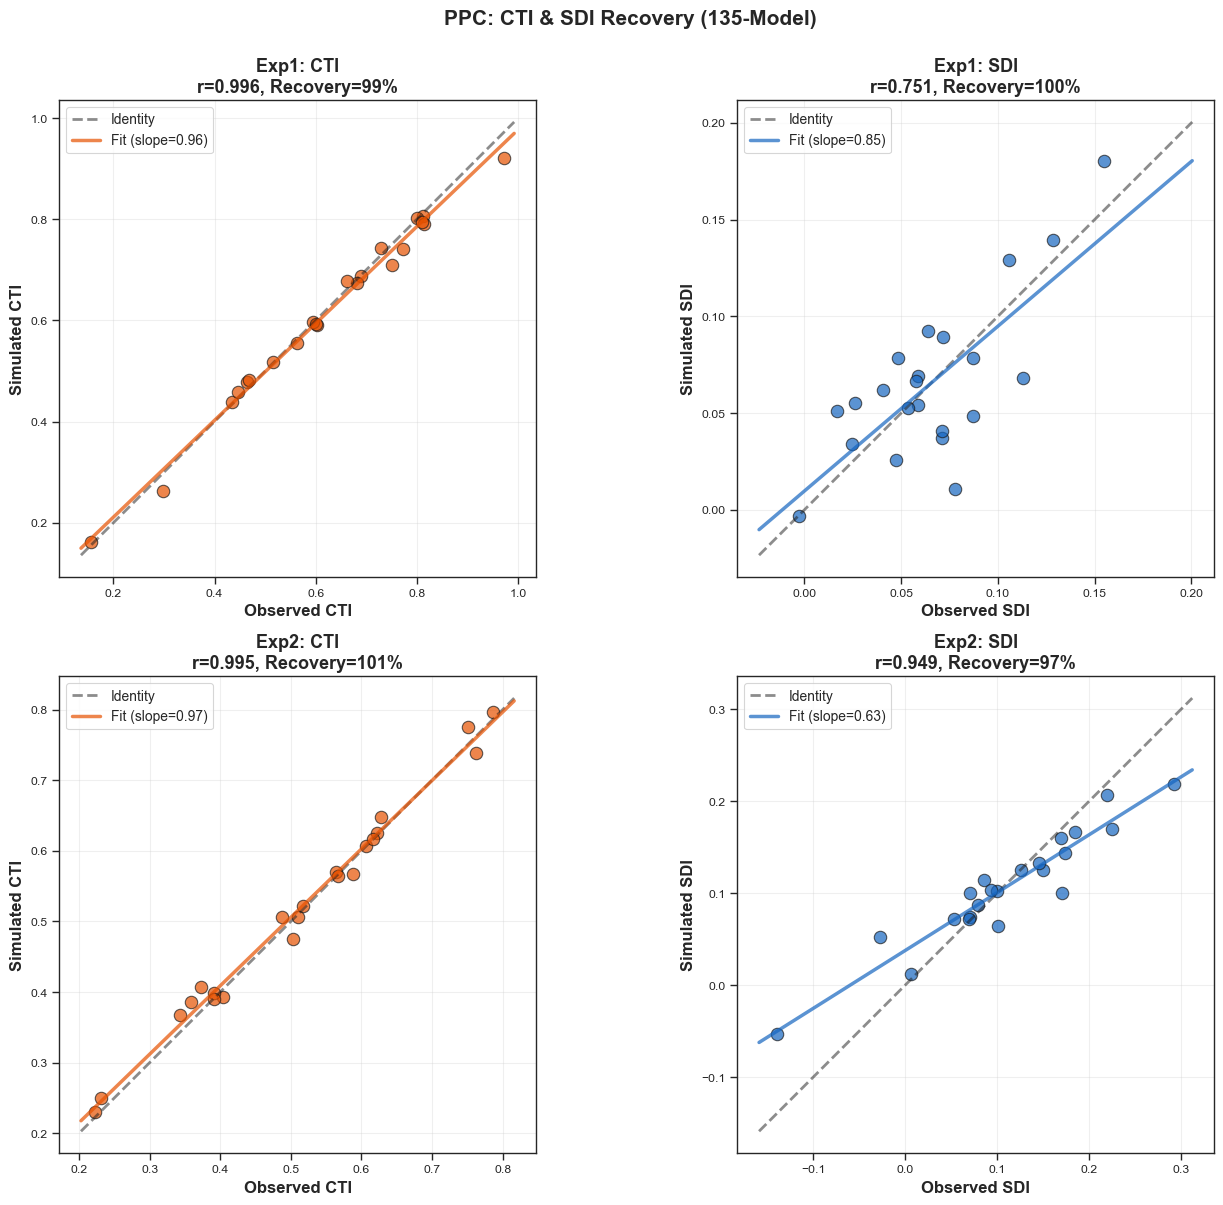

In [ ]:
# PPC Scatter Plots (CTI & SDI)
if results_df is not None and ppc_results:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    for exp_idx, exp in enumerate([1, 2]):
        if exp not in ppc_results:
            continue
        res = ppc_results[exp]
        merged = res['merged']
        
        for metric_idx, (metric, color) in enumerate([('CTI', '#E65100'), ('SDI', '#1565C0')]):
            ax = axes[exp_idx, metric_idx]
            valid = merged.dropna(subset=[f'{metric}_obs', f'{metric}_sim'])
            
            x = valid[f'{metric}_obs']
            y = valid[f'{metric}_sim']
            
            # Scatter
            ax.scatter(x, y, s=80, alpha=0.7, color=color, edgecolors='k', lw=0.8)
            
            # Identity line
            lims = [min(x.min(), y.min()) - 0.02, max(x.max(), y.max()) + 0.02]
            ax.plot(lims, lims, 'k--', alpha=0.5, lw=2, label='Identity')
            
            # Regression line
            if len(valid) > 2:
                slope, intercept = np.polyfit(x, y, 1)
                ax.plot(lims, [slope*l + intercept for l in lims], 
                       color=color, lw=2.5, alpha=0.7, label=f'Fit (slope={slope:.2f})')
            
            ax.set_xlabel(f'Observed {metric}', fontsize=12, fontweight='bold')
            ax.set_ylabel(f'Simulated {metric}', fontsize=12, fontweight='bold')
            ax.set_title(f'Exp{exp}: {metric}\nr={res[f"{metric}_r"]:.3f}, Recovery={res[f"{metric}_rec"]:.0f}%',
                        fontsize=13, fontweight='bold')
            ax.legend(frameon=True, fontsize=10)
            ax.grid(alpha=0.3)
            ax.set_aspect('equal', adjustable='box')
    
    plt.suptitle('PPC: CTI & SDI Recovery (135-Model)', 
                 fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(output_path / 'ppc_cti_sdi_recovery.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('⚠ No PPC results available.')

---
## 7. Summary

In [ ]:
if results_df is not None:
    summary_data = []
    for exp_num in [1, 2]:
        best_model, best_data = get_best_model(results_df, exp_num=exp_num)
        c_id = best_data['c_id'].iloc[0]
        s_id = best_data['s_id'].iloc[0]
        b_id = best_data['b_id'].iloc[0]
        mean_aic = best_data['AIC'].mean()
        n_params = best_data['n_params'].iloc[0]
        
        summary_data.append({
            'Experiment': exp_num,
            'Best Model': best_model,
            'C-Axis': c_id,
            'S-Axis': s_id,
            'B-Axis': b_id,
            'Mean AIC': mean_aic,
            'N Params': n_params,
        })
        
        if exp_num in ppc_results:
            res = ppc_results[exp_num]
            summary_data[-1].update({
                'CTI r': res['CTI_r'],
                'CTI Recovery %': res['CTI_rec'],
                'SDI r': res['SDI_r'],
                'SDI Recovery %': res['SDI_rec'],
            })
    
    display(pd.DataFrame(summary_data))

,Experiment,Best Model,C-Axis,S-Axis,B-Axis,Mean AIC,N Params,CTI r,CTI Recovery %,SDI r,SDI Recovery %
0,1,C_Q1__S_baseline__B_B2,C1,S0,B2,-116.774437,8,0.995612,98.907149,0.751338,99.779556
1,2,C_Q1__S_baseline__B_B2,C1,S0,B2,-76.311239,8,0.994553,101.066813,0.948949,97.146811


### 7.1 Serial Dependence by Condition

Compare observed vs. simulated serial dependence (Bias ~ previous duration) across experimental conditions:
- **Experiment 1**: Repeat vs. Switch (task structure)
- **Experiment 2**: Low vs. High coherence

In [ ]:
# Trial-level serial dependence by condition from saved predictions
def plot_sd_by_condition(data, results_df, exp_num, model_name, ax=None):
    """Plot observed vs saved model-predicted serial dependence by condition.

    Uses results/kalman_model_checks/winner_ppc_trial_predictions.csv.
    Does not generate new simulated responses or run a Kalman filter.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))
    exp_data = trial_predictions[trial_predictions['exp'] == exp_num].copy()
    if exp_data.empty:
        return ax
    exp_data = exp_data.sort_values(['Sub', 'trial_num'])
    exp_data['preDur'] = exp_data.groupby('Sub')['Duration'].shift(1)

    if exp_num == 1:
        cond_col = 'Structure'
        conds = ['Repeat', 'Switch'] if 'Repeat' in set(exp_data['Structure'].dropna()) else ['Same', 'Switch']
        colors = [COLORS.get('same', '#4C78A8'), COLORS.get('switch', '#F58518')] if isinstance(COLORS, dict) else ['#4C78A8', '#F58518']
        title_suffix = 'Task Structure'
    else:
        exp_data['coh_cat'] = np.where(exp_data['coherence'] < 0.5, 'Low', 'High')
        cond_col = 'coh_cat'
        conds = ['Low', 'High']
        colors = [COLORS.get('low', '#54A24B'), COLORS.get('high', '#E45756')] if isinstance(COLORS, dict) else ['#54A24B', '#E45756']
        title_suffix = 'Coherence'

    for i, cond in enumerate(conds):
        cond_df = exp_data[exp_data[cond_col] == cond].dropna(subset=['preDur', 'obs_bias', 'pred_bias'])
        if cond_df.empty:
            continue
        obs = cond_df.groupby('preDur')['obs_bias'].agg(['mean', 'sem']).reset_index()
        pred = cond_df.groupby('preDur')['pred_bias'].agg(['mean', 'sem']).reset_index()
        color = colors[i % len(colors)]
        ax.errorbar(obs['preDur'], obs['mean'], yerr=obs['sem'], marker='o', lw=2, color=color, label=f'{cond} observed')
        ax.errorbar(pred['preDur'], pred['mean'], yerr=pred['sem'], marker='s', lw=2, ls='--', color=color, alpha=.75, label=f'{cond} saved prediction')
    ax.axhline(0, color='black', lw=.8, alpha=.5)
    ax.set_xlabel('Previous duration')
    ax.set_ylabel('Bias')
    ax.set_title(f'Exp {exp_num}: {title_suffix}')
    ax.legend(frameon=False, fontsize=8)
    despine(ax)
    return ax